# Forecasting with foundation models

Foundation models (FMs) have triggered a fundamental paradigm shift in time series forecasting, moving the field away from modelling for each dataset and towards generalised representation learning. Driven by the same architectural breakthroughs that power Large Language Models (LLMs), FMs bring zero-shot and in-context learning capabilities to temporal data.

In the context of forecasting, a foundation model is a massively scaled neural network (typically Transformer-based) that has been pre-trained on highly diverse, cross-domain datasets spanning finance, weather, web traffic, retail and more.

Models such as **Amazon Chronos**, **Google TimesFM 2.5**, **Salesforce Moirai**, and **Soda-INRIA TabICL** frame temporal forecasting as a sequence modelling problem and process temporal data either as quantized discrete tokens (as in Chronos, which applies scalar quantization) or as continuous patch embeddings (as in TimesFM and Moirai, which group consecutive time steps into fixed-length patches before encoding them). Having already internalised the structural priors of millions of series during pre-training, they can instantly infer trends, seasonality and complex dynamics in completely unseen data, eliminating the need for any domain-specific weight updates.

## Foundation Models vs. Machine Learning Models

Foundation models and traditional machine learning models approach forecasting in fundamentally different ways. Understanding these distinctions is crucial for knowing when and how to deploy each method.

**Zero-Shot Prediction**

Machine learning models require a training phase. You must fit the model on your historical target data so the algorithm can learn the optimal weights and parameters for your specific time series. Foundation models, however, are capable of zero-shot inference. Because their highly generalized weights are already frozen from the massive pre-training phase, they can generate accurate forecasts on your data immediately, leveraging their pre-existing latent representations rather than learning your dataset from scratch.

**The Role of the fit Method**

Machine learning models must be trained: calling `.fit()` optimizes the model's internal parameters by minimizing a loss function on your historical data. Foundation models, by contrast, arrive pre-trained: their weights are fixed and are never updated. Calling `.fit()` on a foundation model is not a training step; it simply stores the historical context (observations, frequency, and any scaling factors) needed at inference time. In some implementations, calling `.fit()` is entirely optional before prediction.

**Context Window vs. Engineered Lags**

Machine learning models rely on explicitly engineered features; they require creating a tabular dataset where past values are used as columns to predict the target. Foundation models rely on a **context window**. You pass a raw, sequential chunk of recent historical data (e.g., the last 512 observations) directly into the model at inference time. The attention mechanism inside the model automatically decides which past data points are most relevant.

**In summary**, Foundation models represent a fundamental paradigm shift, replacing the traditional **train → predict** pipeline with a **pre-train → (context + predict)** approach. As major research institutions with access to millions of diverse time series carry out the computationally intensive pre-training phase, end users are completely freed from model training.

However, there is no such thing as a free lunch in machine learning. Skipping the training phase results in a heavier burden during the inference phase. Because their weights are frozen, these models cannot adapt to your data through training. Instead, they adapt implicitly at inference time by processing the historical context through their attention mechanism. Each prediction therefore requires ingesting and attending over a large sequence of raw observations in real time. Consequently, the main drawback of zero-shot forecasting is that the inference process is significantly slower, more computationally expensive and requires your data pipeline to continuously provide large amounts of historical context at runtime.

| - | ML Model | Foundation Model |
|---|---|---|
| **fit** | Trains model, updates weights | Stores context & metadata |
| **predict** | Uses learned weights | Processes context via attention |
| **Data required at train time** | Full history | Not required |
| **Data required at predict time** | Last *lags* observations | Full context window |
| **Computational cost** | At train time | At inference time |

## Impact of the context length

Because foundation forecasting models are highly generalized, they lack intrinsic knowledge of your specific dataset. To compensate, they rely on a **context window**, a specific period of recent historical data, to adapt to your unique scenario at inference time. This context acts as the model's short-term memory, allowing it to calculate the current trajectory of your data and identify whether the series is trending upward, accelerating, or flattening out.

The length of this context window is critical for capturing seasonality and recurring events. To accurately predict a pattern, such as a weekly sales spike or a yearly cycle, the model must actually observe that pattern within the provided history. For instance, if your data has a 365-day seasonality, providing 400 days of context allows the model to recognize and project the cycle, whereas a 30-day window would cause the model to miss the pattern entirely, resulting in a flat or inaccurate forecast.

However, increasing the context length to improve accuracy introduces a significant **computational trade-off**. Because most foundation models are built on Transformer architectures, the computational complexity of their attention mechanism often scales quadratically ($O(N^2)$) with the length of the input sequence. Consequently, doubling the context window can quadruple the required memory and processing power. This quadratic growth means that pushing context lengths to their theoretical maximum often yields diminishing accuracy gains at rapidly increasing computational cost.

Ultimately, effectively utilizing foundation models requires carefully evaluating this trade-off. The best practice is to analyze the context size and select the **shortest possible window that still achieves high predictive performance**. Striking this balance ensures accurate, pattern-aware forecasts while preventing the unnecessary waste of computational resources.

<p style="text-align: center;">
  <img src="../img/prediction_error_vs_context_length.png" alt="Gráfico del error de predicción frente a la longitud del contexto" style="width: 500px; max-width: 100%;">
  <img src="../img/elapsed_time_vs_context_length.png" alt="Gráfico del tiempo transcurrido frente a la longitud del contexto" style="width: 500px; max-width: 100%;">
  <br>
    <font size="2.5"> <i>Comparative charts of prediction error and elapsed time based on context length.</i></font>

</p>

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9999;&#65039; Note</b>
</p>

For more details about foundation models, visit <a href="https://otexts.com/fpppy/nbs/15-foundation-models.html">Forecasting: Principles and Practice, the Pythonic Way</a>.

</div>

## Foundation Models in skforecast

Skforecast's integration is built on two layers. First, [`FoundationModel`](../api/foundationmodel.html) acts as a unified wrapper that adapts each model's native API (Chronos-2, TimesFM 2.5, Moirai-2, TabICL) behind a familiar scikit-learn interface (fit, predict, get_params). Second, [`ForecasterFoundation`](../api/forecasterfoundation.html) wraps that estimator to unlock the full skforecast ecosystem. It exposes the same interface as any other skforecast forecaster, meaning users can use backtesting, prediction intervals, and multi-series support with the exact same code.

<p style="text-align: center;">
  <img src="../img/diagram-foundation-model-architecture.svg" alt="Foundation Model Architecture Diagram" style="max-width: 650px; width: 100%;">
</p>

### Supported Foundation Models

|| Chronos | TimesFM | Moirai | TabICL | TabPFN-TS |
|---|---|---|---|---|---|
| **Provider** | Amazon | Google | Salesforce | Soda-Inria | Prior Labs |
| **GitHub** | [chronos-forecasting](https://github.com/amazon-science/chronos-forecasting) | [timesfm](https://github.com/google-research/timesfm) | [uni2ts](https://github.com/SalesforceAIResearch/uni2ts) | [tabicl](https://github.com/soda-inria/tabicl) | [tabpfn-time-series](https://github.com/PriorLabs/tabpfn-time-series) |
| **Documentation** | [Chronos models](https://huggingface.co/collections/amazon/chronos-models-65f1791d630a8d57cb718444) | [TimesFM models](https://huggingface.co/collections/google/timesfm-release-66e4be5fdb56e960c1e482a6) | [Moirai-R models](https://huggingface.co/collections/Salesforce/moirai-r-models-65c8d3a94c51428c300e0742) | [TabICL Docs](https://tabicl.readthedocs.io/en/latest/) | [Prior Labs Docs](https://docs.priorlabs.ai/) |
| **Available model IDs** | amazon/chronos-2<br>autogluon/chronos-2-small<br>autogluon/chronos-2-synth | google/timesfm-2.5-200m-pytorch | Salesforce/moirai-2.0-R-small | soda-inria/tabicl | priorlabs/tabpfn-ts |
| **Backend** | PyTorch | PyTorch | PyTorch | PyTorch | PyTorch |
| **Forecasting type** | Zero-shot | Zero-shot | Zero-shot | Zero-shot | Zero-shot |
| **Default context_length** | 8192 | 512 | 2048 | 4096 | 32768 |
| **Max context_length** | 8192 | 16384 | 2048 | 4096 | No hard limit (practical memory ceiling ~65536) |
| **max_horizon** | No hard limit, set via `steps` at predict time | 512 | No hard limit, set via `steps` at predict time | No hard limit, set via `steps` at predict time | No hard limit, set via `steps` at predict time |
| **Point forecast** | Median (0.5 quantile) | Mean (dedicated output array) | Median (0.5 quantile) | Mean (default, configurable to median) | Median (default, configurable to mean/mode) |
| **Covariate support (exog)** | Yes | No | No | Yes | Yes |
| **cross_learning parameter** | Yes (multi-series mode only) | No | No | No | No |
| **Install command** | `pip install chronos-forecasting` | `pip install git+https://github.com/google-research/timesfm.git` | `pip install uni2ts` | `pip install tabicl[forecast]` | `pip install tabpfn-time-series` |

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

All four models run on the CPU. However, a CUDA GPU is recommended for faster inference, especially with long context windows. The MPS backend is also detected automatically by <code>PyTorch</code> and can benefit Apple Silicon users.

It is important to note that context length significantly impacts inference speed. Larger contexts provide the models with more information, but they increase processing time. Although these models boast massive context capacities, shorter contexts often achieve similar results much faster for most use cases.


</div>

### Input Data Formats

`ForecasterFoundation` accepts several data formats for both the target series and exogenous variables.

**Target Series (`series`)**

The `series` parameter in the `.fit()` method supports both single-series and multi-series (global model) configurations.

| Mode | Allowed Data Type | Description |
| :--- | :--- | :--- |
| **Single-Series** | `pd.Series` | A single time series with a named index. |
| **Multi-Series (Wide)** | `pd.DataFrame` | Each column represents a separate time series. |
| **Multi-Series (Long)** | `pd.DataFrame` | MultiIndex (Level 0: series ID, Level 1: DatetimeIndex). |
| **Multi-Series (Dict)** | `dict[str, pd.Series]` | Keys are series identifiers, values are pandas Series. |

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

While Long-format DataFrames are supported, they are converted to dictionaries internally. For best performance, pass a <code>dict[str, pd.Series]</code> directly.

</div>

**Exogenous Variables (`exog`)**

Exogenous variables must be aligned with the target series index. Currently, only **Chronos** and **TabICL** support covariates (see the [Supported Foundation Models](#supported-foundation-models) table). TimesFM and Moirai do not accept exogenous variables.\n

| Mode | Allowed Data Type | Description |
| :--- | :--- | :--- |
| **Single-Series** | `pd.Series` or `pd.DataFrame` | Aligned to the target series index. |
| **Multi-Series (Dict)** | `dict[str, pd.Series \| pd.DataFrame \| None]` | One entry per series. |
| **Multi-Series (Broadcast)** | `pd.Series` or `pd.DataFrame` | Automatically applied to all series. |
| **Multi-Series (Long)** | `pd.DataFrame` | MultiIndex (Level 0: series ID, Level 1: DatetimeIndex). |

## Libraries and data

In [50]:
# Libraries
# ==============================================================================
import pandas as pd
import torch
import time
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_foundation
)
from skforecast.plot import set_dark_theme

color = '\033[1m\033[38;5;208m' 
print(f"{color}torch version: {torch.__version__}")
print(f"  Cuda available : {torch.cuda.is_available()}")
print(f"  MPS available  : {torch.backends.mps.is_available()}")

torch version: 2.6.0+cu124
  Cuda available : True
  MPS available  : False


In [2]:
# Data download
# ==============================================================================
data = fetch_dataset(name='vic_electricity')

# Aggregating in 1H intervals
# ==============================================================================
# The Date column is eliminated so that it does not generate an error when aggregating.
data = data.drop(columns="Date")
data = (
    data
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Holiday
Time,,,
2011-12-31 14:00:00,4323.095350,21.225,1.0
2011-12-31 15:00:00,3963.264688,20.625,1.0
2011-12-31 16:00:00,3950.913495,20.325,1.0


In [3]:
# Split data into train-test
# ==============================================================================
data = data.loc['2012-01-01 00:00:00':'2014-12-30 23:00:00', :].copy()
end_train = '2014-11-30 23:59:00'
data_train = data.loc[: end_train, :].copy()
data_test  = data.loc[end_train:, :].copy()

print(f"Train dates: {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")


Train dates: 2012-01-01 00:00:00 --- 2014-11-30 23:00:00  (n=25560)
Test dates : 2014-12-01 00:00:00 --- 2014-12-30 23:00:00  (n=720)


## Chronos

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Amazon's **Chronos-2-small** model.

In [4]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="autogluon/chronos-2-small", context_length=500)
forecaster = ForecasterFoundation(estimator=estimator)

Each adapter accepts **additional keyword arguments** that control model-specific behavior (e.g., `context_length`, `device_map`, `torch_dtype`). These can be passed directly through the `FoundationModel` constructor. 

For the full list of available parameters, see the API reference: [ChronosAdapter](../api/FoundationModel.html#skforecast.foundation._adapters.ChronosAdapter), [TimesFMAdapter](../api/FoundationModel.html#skforecast.foundation._adapters.TimesFMAdapter), [MoiraiAdapter](../api/FoundationModel.html#skforecast.foundation._adapters.MoiraiAdapter), [TabICLAdapter](../api/FoundationModel.html#skforecast.foundation._adapters.TabICLAdapter).

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>

<p>
While <code>.fit()</code> is used here to store the historical context and metadata, it is not strictly required. Foundation models can generate forecasts by passing the context directly to <code>.predict()</code> via the <code>context</code> parameter. However, calling <code>.fit()</code> first simplifies subsequent calls to <code>.predict()</code>, <code>.predict_interval()</code>, and <code>.predict_quantiles()</code>.
</p>

</div>

In [5]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(
    series = data_train["Demand"], 
    exog   = data_train[["Temperature", "Holiday"]]
)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: autogluon/chronos-2-small 
Context length: 500 
Series names: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-06-11 22:10:03 
Last fit date: 2026-06-11 22:10:03 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

Three methods can be used to predict the next $n$ steps ahead: `predict()`, `predict_interval()`, and `predict_quantiles()`. All these methods allow for passing `context` and `context_exog` to override the historical context used by the underlying model to generate predictions.

In [6]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(
                  steps = steps,
                  exog  = data_test[["Temperature", "Holiday"]]
              )

predictions.head(3)

,level,pred
2014-12-01 00:00:00,Demand,5527.678711
2014-12-01 01:00:00,Demand,5511.500977
2014-12-01 02:00:00,Demand,5457.791992


In [7]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = steps,
                            exog     = data_test[["Temperature", "Holiday"]],
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5527.678711,5372.815918,5689.793457
2014-12-01 01:00:00,Demand,5511.500977,5318.045410,5733.492188
2014-12-01 02:00:00,Demand,5457.791992,5241.040527,5717.424805


### Backtesting

Backtesting with foundation models works differently than with traditional machine learning forecasters. Since the model's weights are frozen and never updated, the concept of **refitting** does not apply. The `refit` and `fixed_train_size` arguments in `TimeSeriesFold` are ignored internally.

Instead, what changes across folds is the **context window**. As backtesting progresses, the amount of historical data available grows. At each fold, the model receives the most recent observations up to the fold boundary. This process has two phases: first, the context **expands** as more historical data becomes available with each fold; once the available history exceeds the model's `context_length`, the context **stops growing** and instead **slides forward**, always using the last `context_length` observations before the fold boundary.

<p style="text-align: center">
    <img src="../img/time-series-backtesting-forecasting-foundation.gif" style="width: 650px; max-width: 100%;">
    <br>
    <font size="2.5"> <i>Backtesting with expanding context window.</i></font>
</p>

To learn more about backtesting, visit the [backtesting user guide](../user_guides/backtesting.html).

In [8]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_chronos, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    exog              = data[["Temperature", "Holiday"]],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_chronos)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/30 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,171.266953



Backtest predictions


,level,fold,pred
2014-12-01 00:00:00,Demand,0,5527.678711
2014-12-01 01:00:00,Demand,0,5511.500977
2014-12-01 02:00:00,Demand,0,5457.791992
2014-12-01 03:00:00,Demand,0,5402.819336


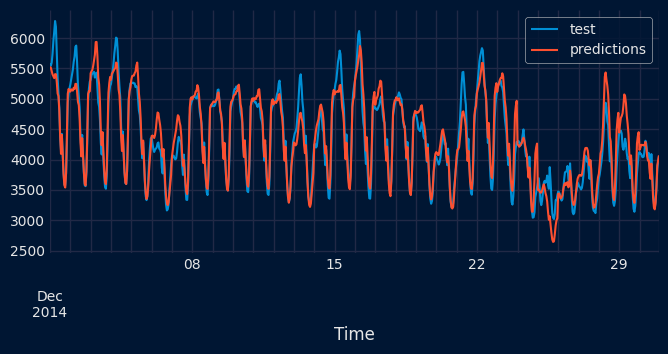

In [9]:
# Plot predictions
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data_test['Demand'].plot(ax=ax, label='test')
backtest_predictions['pred'].plot(ax=ax, label='predictions')
ax.legend();

### Multiple series (global model)

The class <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> allows modeling and forecasting multiple series with a single model.

In [10]:
# Data
# ==============================================================================
data_multiseries = fetch_dataset(name="items_sales")
display(data_multiseries.head(3))

╭─────────────────────── items_sales ───────────────────────╮
│ Description:                                              │
│ Simulated time series for the sales of 3 different items. │
│                                                           │
│ Source:                                                   │
│ Simulated data.                                           │
│                                                           │
│ URL:                                                      │
│ https://raw.githubusercontent.com/skforecast/skforecast-  │
│ datasets/main/data/simulated_items_sales.csv              │
│                                                           │
│ Shape: 1097 rows x 3 columns                              │
╰───────────────────────────────────────────────────────────╯

,item_1,item_2,item_3
date,,,
2012-01-01,8.253175,21.047727,19.429739
2012-01-02,22.777826,26.578125,28.009863
2012-01-03,27.549099,31.751042,32.078922


In [11]:
# Split data into train-test
# ==============================================================================
end_train = '2014-07-15 23:59:00'
data_multiseries_train = data_multiseries.loc[:end_train, :]
data_multiseries_test  = data_multiseries.loc[end_train:, :]

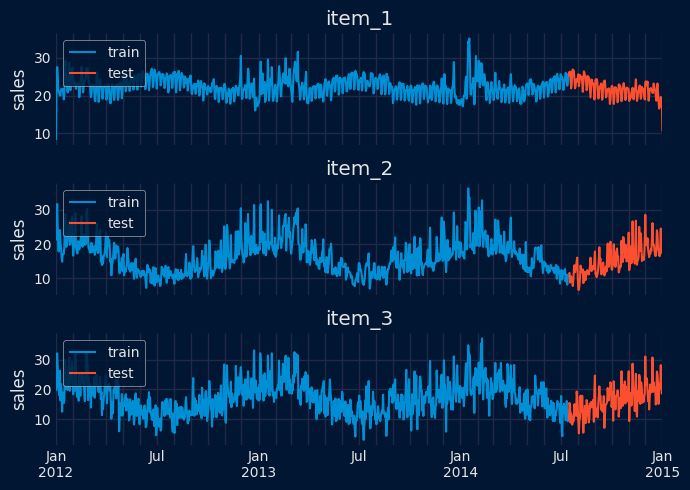

In [12]:
# Plot time series
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 5), sharex=True)

for i, col in enumerate(data_multiseries.columns):
    data_multiseries_train[col].plot(ax=axes[i], label='train')
    data_multiseries_test[col].plot(ax=axes[i], label='test')
    axes[i].set_title(col)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper left')

fig.tight_layout()
plt.show();

In this example, instead of calling `fit()`, the context is passed directly to the `predict()` method.

In [13]:
# Create and train ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id = "autogluon/chronos-2-small", context_length=500)
forecaster = ForecasterFoundation(estimator = estimator)

# fit() is optional; context is passed directly to predict()
# forecaster.fit(series=data_multiseries_train)

forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: autogluon/chronos-2-small 
Context length: 500 
Series names: None 
Exogenous included: False 
Exogenous names: None 
Context range: None 
Training index type: None 
Training index frequency: None 
Creation date: 2026-06-11 22:10:19 
Last fit date: None 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

In [14]:
# Predictions for all series (levels)
# ==============================================================================
steps = len(data_multiseries_test)
predictions_items = forecaster.predict(
                        steps   = len(data_multiseries_test), 
                        levels  = None,  # All levels are predicted
                        context = data_multiseries_train
                    )

predictions_items.head()

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\miniconda3\envs\skforecast_22_py12\Lib\site-packages\skforecast\uti │
│ ls\utils.py:2967                                                                     │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,level,pred
2014-07-16,item_1,25.523064
2014-07-16,item_2,10.456666
2014-07-16,item_3,11.862236
2014-07-17,item_1,25.296782
2014-07-17,item_2,10.701235


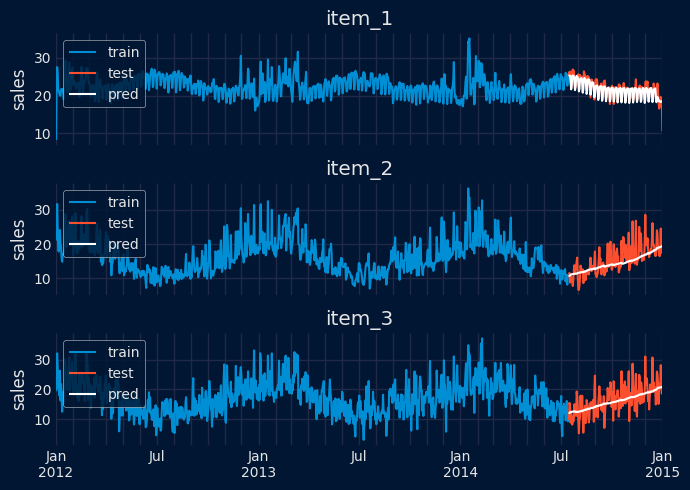

In [15]:
# Plot predictions
# ==============================================================================
set_dark_theme()
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 5), sharex=True)

for i, col in enumerate(data_multiseries.columns):
    
    data_multiseries_train[col].plot(ax=axes[i], label='train')
    data_multiseries_test[col].plot(ax=axes[i], label='test')
    predictions_items.query(f"level == '{col}'").plot(
        ax=axes[i], label='predictions', color='white'
    )

    axes[i].set_title(col)
    axes[i].set_ylabel('sales')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper left')

fig.tight_layout()
plt.show();

In [16]:
# Interval predictions for item_1 and item_2
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = 24,
                            levels   = ['item_1', 'item_2'],
                            context  = data_multiseries_train,
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head()

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\Joaquin\miniconda3\envs\skforecast_22_py12\Lib\site-packages\skforecast\uti │
│ ls\utils.py:2967                                                                     │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,level,pred,lower_bound,upper_bound
2014-07-16,item_1,25.464174,24.582005,26.430853
2014-07-16,item_2,10.649370,8.679634,13.302807
2014-07-17,item_1,25.270247,24.255964,26.327969
2014-07-17,item_2,10.834244,8.717453,13.826941
2014-07-18,item_1,25.175861,24.079086,26.286255


## Other foundation models

The examples above use the Amazon Chronos model, but the same code structure applies to any other foundation model supported by skforecast. The following subsections demonstrate that the pipeline is identical regardless of the underlying model; only the `model_id` changes. To use a different model, simply pass it when instantiating the <code>[FoundationModel](../api/foundationmodel.html)</code> wrapper.

### TimesFM 2.5

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Google's **TimesFM-2.5-200m** model.

In [17]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="google/timesfm-2.5-200m-pytorch", context_length=500)
forecaster = ForecasterFoundation(estimator = estimator)

In [18]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(series=data_train["Demand"])
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: google/timesfm-2.5-200m-pytorch 
Context length: 500 
Series names: Demand 
Exogenous included: False 
Exogenous names: None 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-06-11 22:10:20 
Last fit date: 2026-06-11 22:10:20 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

In [19]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(steps=steps)
predictions.head(3)

,level,pred
2014-12-01 00:00:00,Demand,5658.415039
2014-12-01 01:00:00,Demand,5671.861816
2014-12-01 02:00:00,Demand,5747.938477


In [20]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5658.415039,5541.004883,5790.344238
2014-12-01 01:00:00,Demand,5671.861816,5470.189453,5899.113281
2014-12-01 02:00:00,Demand,5747.938477,5450.534180,6064.879883


In [21]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_timesfm, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_timesfm)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/168 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,160.357018



Backtest predictions


,level,fold,pred
2014-07-16 00:00:00,Demand,0,6189.843750
2014-07-16 01:00:00,Demand,0,5988.112793
2014-07-16 02:00:00,Demand,0,5830.692383
2014-07-16 03:00:00,Demand,0,5696.288086


### Moirai

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Salesforce's **Moirai-2.0-R-small** model.

In [22]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="Salesforce/moirai-2.0-R-small", context_length=500)
forecaster = ForecasterFoundation(estimator=estimator)

In [23]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(series=data_train["Demand"])
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: Salesforce/moirai-2.0-R-small 
Context length: 500 
Series names: Demand 
Exogenous included: False 
Exogenous names: None 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-06-11 22:10:49 
Last fit date: 2026-06-11 22:10:50 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

In [24]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(steps=steps)
predictions.head(3)

,level,pred
2014-12-01 00:00:00,Demand,5731.725098
2014-12-01 01:00:00,Demand,5870.827148
2014-12-01 02:00:00,Demand,5959.207031


In [25]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
    steps    = steps,
    interval = [10, 90],  # 80% prediction interval
)
predictions_intervals.head(3)

,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5731.725098,5517.737793,5940.646484
2014-12-01 01:00:00,Demand,5870.827148,5548.743164,6176.801270
2014-12-01 02:00:00,Demand,5959.207031,5599.376953,6323.206055


In [26]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_moirai, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_moirai)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

  0%|          | 0/168 [00:00<?, ?it/s]

Backtest metrics


,mean_absolute_error
0,161.691106



Backtest predictions


,level,fold,pred
2014-07-16 00:00:00,Demand,0,6222.097656
2014-07-16 01:00:00,Demand,0,6114.366699
2014-07-16 02:00:00,Demand,0,5969.839844
2014-07-16 03:00:00,Demand,0,5920.479492


### TabICL

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Soda-Inria's **TabICL** model.

In [27]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="soda-inria/tabicl", context_length=500)
forecaster = ForecasterFoundation(estimator=estimator)

In [28]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(
    series = data_train["Demand"], 
    exog   = data_train[["Temperature", "Holiday"]]
)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: soda-inria/tabicl 
Context length: 500 
Series names: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-06-11 22:10:55 
Last fit date: 2026-06-11 22:10:55 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

In [29]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(
                  steps = steps,
                  exog  = data_test[["Temperature", "Holiday"]]
              )

predictions.head(3)

GPU 0:: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


,level,pred
2014-12-01 00:00:00,Demand,5590.919922
2014-12-01 01:00:00,Demand,5662.487305
2014-12-01 02:00:00,Demand,5661.673828


In [30]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = steps,
                            exog     = data_test[["Temperature", "Holiday"]],
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head(3)

GPU 0:: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5617.177246,5159.889160,5952.955078
2014-12-01 01:00:00,Demand,5678.133301,5215.843750,6059.711914
2014-12-01 02:00:00,Demand,5677.455078,5131.911133,6149.854492


In [ ]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_tabicl, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    exog              = data[["Temperature", "Holiday"]],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_tabicl)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

### TabPFN-TS

A <code>[ForecasterFoundation](../api/forecasterfoundation.html)</code> is created using Prior Labs' **TabPFN-TS** model. TabPFN-TS frames forecasting as tabular regression: the series is featurized (running index, calendar features, automatically detected seasonal features) and a TabPFN regressor predicts the forecast horizon zero-shot. By default inference runs locally (`mode='local'`, CUDA > MPS > CPU); pass `mode='client'` to use the Prior Labs cloud API instead (no GPU needed, requires an API key).

In [42]:
# Create ForecasterFoundation
# ==============================================================================
estimator = FoundationModel(model_id="priorlabs/tabpfn-ts", context_length=500)
forecaster = ForecasterFoundation(estimator=estimator)

In [43]:
# Train ForecasterFoundation
# ==============================================================================
forecaster.fit(
    series = data_train["Demand"], 
    exog   = data_train[["Temperature", "Holiday"]]
)
forecaster

==================== 
ForecasterFoundation 
==================== 
Model ID: priorlabs/tabpfn-ts 
Context length: 500 
Series names: Demand 
Exogenous included: True 
Exogenous names: Temperature, Holiday 
Context range: {'Demand': [Timestamp('2012-01-01 00:00:00'), Timestamp('2014-11-30 23:00:00')]} 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-06-11 22:22:42 
Last fit date: 2026-06-11 22:22:42 
Skforecast version: 0.23.0 
Python version: 3.12.13 
Forecaster id: None

In [45]:
# Predictions: point forecast
# ==============================================================================
steps = 24
predictions = forecaster.predict(
                  steps = steps,
                  exog  = data_test[["Temperature", "Holiday"]]
              )

predictions.head(3)

GPU 0:: 100%|██████████| 1/1 [00:01<00:00,  1.76s/it]


,level,pred
2014-12-01 00:00:00,Demand,5501.075195
2014-12-01 01:00:00,Demand,5492.506348
2014-12-01 02:00:00,Demand,5451.953613


In [46]:
# Predictions: intervals
# ==============================================================================
predictions_intervals = forecaster.predict_interval(
                            steps    = steps,
                            exog     = data_test[["Temperature", "Holiday"]],
                            interval = [10, 90],  # 80% prediction interval
                        )

predictions_intervals.head(3)

GPU 0:: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


,level,pred,lower_bound,upper_bound
2014-12-01 00:00:00,Demand,5501.075195,4921.248047,5719.331055
2014-12-01 01:00:00,Demand,5492.506348,4891.378418,5775.401367
2014-12-01 02:00:00,Demand,5451.953613,4855.321289,5793.561523


In [ ]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

metrics_tabpfn, backtest_predictions = backtesting_foundation(
    forecaster        = forecaster,
    series            = data['Demand'],
    exog              = data[["Temperature", "Holiday"]],
    cv                = cv,
    metric            = 'mean_absolute_error',
    suppress_warnings = True
)

print("Backtest metrics")
display(metrics_tabpfn)
print("")
print("Backtest predictions")
backtest_predictions.head(4)

## Model comparison

The following table summarizes the backtesting results (Mean Absolute Error) for the five foundation models on the same dataset.

In [49]:
# Comparison of backtesting metrics
# ==============================================================================
comparison = pd.DataFrame({
    "Model": [
        "Chronos-2 (small)*",
        "TimesFM-2.5 (200m)",
        "Moirai-2.0-R (small)",
        "TabICLv2*",
        "TabPFN-TS*"
    ],
    "mean_absolute_error": [
        metrics_chronos["mean_absolute_error"].iloc[0],
        metrics_timesfm["mean_absolute_error"].iloc[0],
        metrics_moirai["mean_absolute_error"].iloc[0],
        metrics_tabicl["mean_absolute_error"].iloc[0],
        metrics_tabpfn["mean_absolute_error"].iloc[0]
    ],
}).sort_values(by="mean_absolute_error")

comparison.style.highlight_min(
    subset="mean_absolute_error", color="green"
).format(precision=4)

,Model,mean_absolute_error
4,TabPFN-TS*,158.7035
1,TimesFM-2.5 (200m),160.3570
2,Moirai-2.0-R (small),161.6911
3,TabICLv2*,170.1016
0,Chronos-2 (small)*,171.2670


\* Chronos-2 (small), TabICLv2 and TabPFN-TS are the only ones that allow to include exogenous features.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning: Data Leakage</b>
</p>

These examples use a widely available public dataset for illustrative purposes. It is highly probable that the foundation models were exposed to these data points during their pre-training phase. As a result, the predictions may be more optimistic than what would be achieved in a real-world production environment with private or novel data.

</div>

## Selection of context length

As described in the *Impact of the context length* section, the context length has a direct effect on both the model's predictive accuracy and the computation time required to generate forecasts. Furthermore, because the context must be sent to the model every time a prediction is made, it also increases the amount of data transferred when the model is deployed in production.

It is therefore important to identify the optimal context length that strikes a good balance between predictive accuracy and inference time.